In [41]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent / "src"))
from common import PROCESSED, FIGURES, RESULTS, SEED

FEATURES = ["FIFA_Points_Diff", "Stage_Level", "Rest_Days_Diff",
            "Home_Country_Advantage_Diff", "Same_Confederation",
            "Squad_Age_Diff", "Avg_GF_Before_Diff", "Avg_GA_Before_Diff"]
TARGET = "Goal_Diff"

df = pd.read_csv(PROCESSED / "model_task21_goal_diff.csv")
assert len(df) == 104, len(df)
assert len(FEATURES) == 8
missing = [c for c in FEATURES + [TARGET] if c not in df.columns]
assert not missing, f"Missing columns: {missing}"
assert df[FEATURES + [TARGET]].isna().sum().sum() == 0

FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)
print(df.shape)
df[FEATURES + [TARGET]].describe().round(2).T

(104, 12)


,count,mean,std,min,25%,50%,75%,max
FIFA_Points_Diff,104.0,55.19,231.49,-489.53,-127.75,67.76,232.26,506.16
Stage_Level,104.0,1.59,1.08,1.00,1.00,1.00,2.00,6.00
Rest_Days_Diff,104.0,0.10,0.47,-1.00,0.00,0.00,0.00,2.00
Home_Country_Advantage_Diff,104.0,0.07,0.35,-1.00,0.00,0.00,0.00,1.00
Same_Confederation,104.0,0.12,0.32,0.00,0.00,0.00,0.00,1.00
Squad_Age_Diff,104.0,-0.08,1.80,-4.50,-1.40,0.15,1.10,3.60
Avg_GF_Before_Diff,104.0,0.02,0.62,-2.25,-0.25,0.00,0.33,2.00
Avg_GA_Before_Diff,104.0,-0.08,0.56,-2.00,-0.33,0.00,0.14,1.50
Goal_Diff,104.0,0.48,2.02,-4.00,-1.00,0.00,2.00,6.00


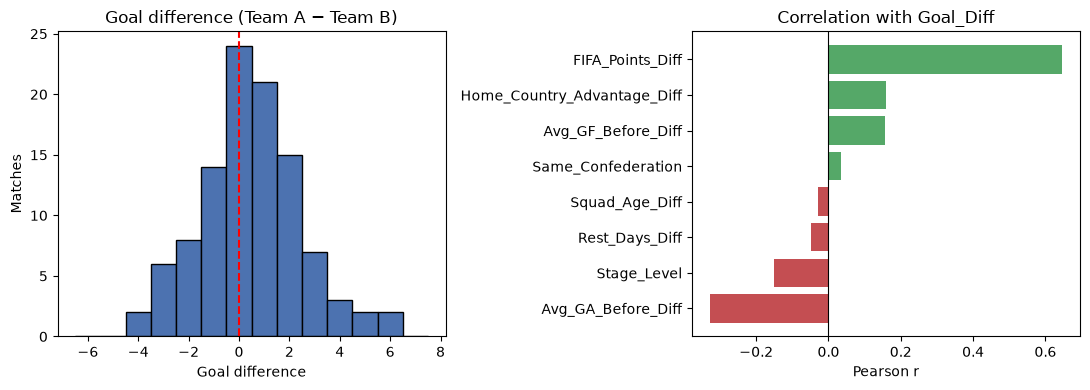

Mean goal difference: 0.48
Draws (Goal_Diff = 0): 24 of 104
Avg_GA_Before_Diff            -0.33
Stage_Level                   -0.15
Rest_Days_Diff                -0.05
Squad_Age_Diff                -0.03
Same_Confederation             0.03
Avg_GF_Before_Diff             0.16
Home_Country_Advantage_Diff    0.16
FIFA_Points_Diff               0.65


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: distribution of the target
axes[0].hist(df[TARGET], bins=np.arange(-6.5, 8.5, 1), edgecolor="black", color="#4C72B0")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Goal difference (Team A − Team B)")
axes[0].set_xlabel("Goal difference")
axes[0].set_ylabel("Matches")

# Right: raw correlation of each feature with the target
corr = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
axes[1].barh(corr.index, corr.values, color=["#C44E52" if v < 0 else "#55A868" for v in corr.values])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlation with Goal_Diff")
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.savefig(FIGURES / "task21_eda.png", dpi=150)
plt.show()

print("Mean goal difference:", round(df[TARGET].mean(), 2))
print("Draws (Goal_Diff = 0):", int((df[TARGET] == 0).sum()), "of", len(df))
print(corr.round(2).to_string())

In [43]:
from scipy import stats

def fit_ols(data, features, target):
    X = np.column_stack([np.ones(len(data)), data[features].to_numpy(float)])
    y = data[target].to_numpy(float)
    n, k = X.shape
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    resid = y - X @ beta
    sigma2 = resid @ resid / (n - k)
    se = np.sqrt(np.diag(XtX_inv) * sigma2)
    t = beta / se
    p = 2 * stats.t.sf(np.abs(t), n - k)
    tcrit = stats.t.ppf(0.975, n - k)
    r2 = 1 - resid @ resid / ((y - y.mean()) ** 2).sum()
    adj = 1 - (1 - r2) * (n - 1) / (n - k)
    f = (r2 / (k - 1)) / ((1 - r2) / (n - k))
    table = pd.DataFrame({"coef": beta, "std_err": se, "t": t, "p_value": p,
                          "ci_low": beta - tcrit * se, "ci_high": beta + tcrit * se},
                         index=["Intercept"] + list(features))
    stats_out = dict(r2=r2, adj_r2=adj, f=f, f_p=stats.f.sf(f, k - 1, n - k),
                     n=n, k=k - 1, resid=resid, fitted=X @ beta)
    return table, stats_out

table, s = fit_ols(df, FEATURES, TARGET)
table.round(3).to_csv(RESULTS / "task21_ols_table.csv")
print(table.round(3).to_string())
print(f"\nR2 = {s['r2']:.3f} | Adj R2 = {s['adj_r2']:.3f} | F = {s['f']:.2f} (p = {s['f_p']:.2g}) | n = {s['n']}")

                              coef  std_err      t  p_value  ci_low  ci_high
Intercept                    0.601    0.279  2.158    0.033   0.048    1.154
FIFA_Points_Diff             0.006    0.001  7.316    0.000   0.004    0.007
Stage_Level                 -0.379    0.161 -2.347    0.021  -0.699   -0.058
Rest_Days_Diff               0.382    0.356  1.073    0.286  -0.325    1.089
Home_Country_Advantage_Diff  0.637    0.448  1.422    0.158  -0.252    1.526
Same_Confederation           0.581    0.502  1.157    0.250  -0.416    1.577
Squad_Age_Diff               0.023    0.086  0.264    0.793  -0.149    0.194
Avg_GF_Before_Diff          -0.328    0.273 -1.203    0.232  -0.869    0.213
Avg_GA_Before_Diff          -0.386    0.294 -1.312    0.193  -0.971    0.198

R2 = 0.481 | Adj R2 = 0.437 | F = 11.00 (p = 7.2e-11) | n = 104


In [44]:
EXPECTED = {"FIFA_Points_Diff": "+", "Stage_Level": "?", "Rest_Days_Diff": "+",
            "Home_Country_Advantage_Diff": "+", "Same_Confederation": "?",
            "Squad_Age_Diff": "?", "Avg_GF_Before_Diff": "+", "Avg_GA_Before_Diff": "-"}

rows = []
for f in FEATURES:
    b, p = table.loc[f, "coef"], table.loc[f, "p_value"]
    sign = "+" if b > 0 else "-"
    exp = EXPECTED[f]
    direction = "no expectation" if exp == "?" else ("as expected" if exp == sign else "OPPOSITE")
    rows.append({"variable": f, "expected": exp, "coef": round(b, 3), "p_value": round(p, 3),
                 "decision (5%)": "Reject H0" if p < 0.05 else "Fail to reject H0",
                 "direction": direction})

hyp_results = pd.DataFrame(rows)
hyp_results.to_csv(RESULTS / "task21_hypotheses_vs_results.csv", index=False)
print(hyp_results.to_string(index=False))

                   variable expected   coef  p_value     decision (5%)      direction
           FIFA_Points_Diff        +  0.006    0.000         Reject H0    as expected
                Stage_Level        ? -0.379    0.021         Reject H0 no expectation
             Rest_Days_Diff        +  0.382    0.286 Fail to reject H0    as expected
Home_Country_Advantage_Diff        +  0.637    0.158 Fail to reject H0    as expected
         Same_Confederation        ?  0.581    0.250 Fail to reject H0 no expectation
             Squad_Age_Diff        ?  0.023    0.793 Fail to reject H0 no expectation
         Avg_GF_Before_Diff        + -0.328    0.232 Fail to reject H0       OPPOSITE
         Avg_GA_Before_Diff        - -0.386    0.193 Fail to reject H0    as expected


In [45]:
import sys; print(sys.executable)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedKFold, cross_validate

X, y = df[FEATURES], df[TARGET]

models = {
    "Baseline (mean)": DummyRegressor(strategy="mean"),
    "OLS": LinearRegression(),
    "Ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30))),
    "Lasso": make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=SEED, max_iter=20000)),
    "Random forest": RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                                           random_state=SEED, n_jobs=-1),
}

cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=SEED)
rows = []
for name, model in models.items():
    r = cross_validate(model, X, y, cv=cv,
                       scoring=("neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"))
    rows.append({"model": name,
                 "RMSE": -r["test_neg_root_mean_squared_error"].mean(),
                 "RMSE_sd": r["test_neg_root_mean_squared_error"].std(),
                 "MAE": -r["test_neg_mean_absolute_error"].mean(),
                 "R2": r["test_r2"].mean()})

cv_results = pd.DataFrame(rows).round(3)
cv_results.to_csv(RESULTS / "task21_model_comparison.csv", index=False)
print(cv_results.to_string(index=False))

/Users/arpann22/Desktop/HIT140-WorldCup2026/venv/bin/python
          model  RMSE  RMSE_sd   MAE     R2
Baseline (mean) 2.019    0.273 1.592 -0.072
            OLS 1.590    0.248 1.253  0.310
          Ridge 1.589    0.252 1.257  0.318
          Lasso 1.604    0.230 1.268  0.305
  Random forest 1.616    0.223 1.285  0.290


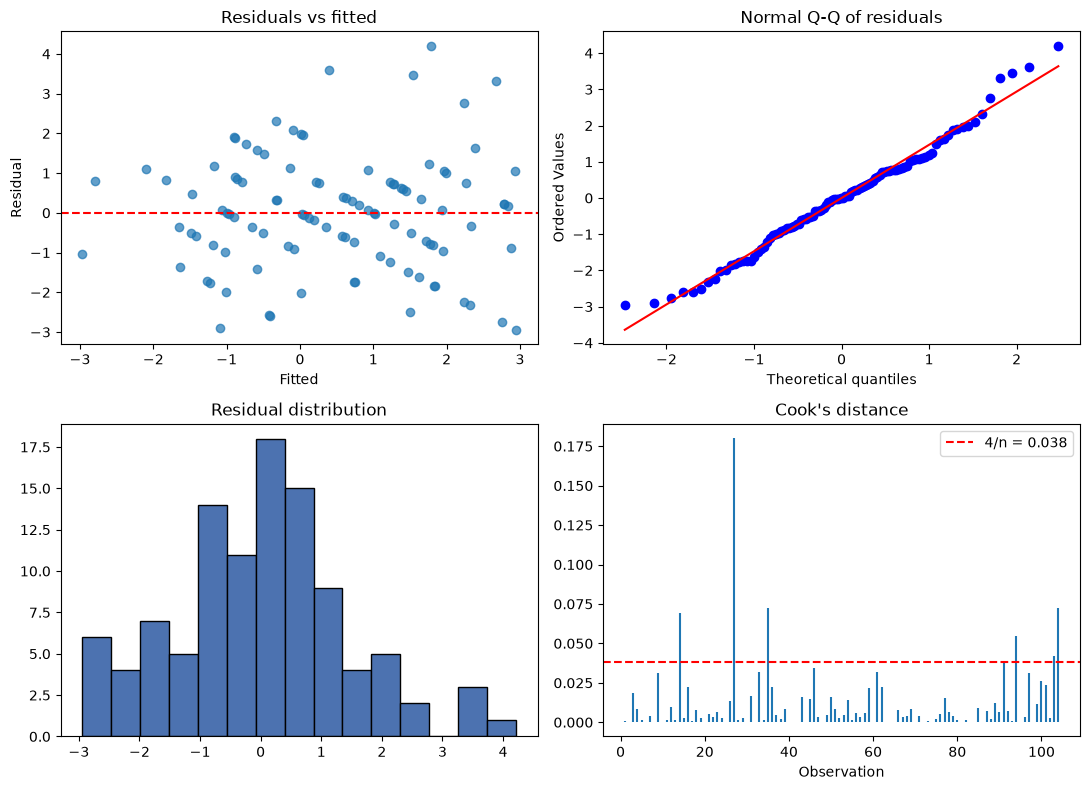

Shapiro-Wilk  W = 0.985, p = 0.289
Breusch-Pagan LM = 10.49, p = 0.232
Durbin-Watson = 2.27

VIF:
FIFA_Points_Diff               1.41
Stage_Level                    1.37
Rest_Days_Diff                 1.27
Home_Country_Advantage_Diff    1.09
Same_Confederation             1.16
Squad_Age_Diff                 1.07
Avg_GF_Before_Diff             1.27
Avg_GA_Before_Diff             1.23

Influential matches (Cook's D > 4/n): 6
 Match_ID  Team_A     Team_B  Goal_Diff  cooks
       27  Canada      Qatar          6  0.180
       35 Ecuador    Curacao          0  0.072
      104   Spain  Argentina          1  0.072
       14   Spain Cabo Verde          0  0.069
       94     USA    Belgium         -3  0.055
      103  France    England         -2  0.042


In [46]:
resid, fitted = s["resid"], s["fitted"]
n, k = s["n"], s["k"] + 1                      # k includes the intercept

# 1) Normality of residuals
sw_stat, sw_p = stats.shapiro(resid)

# 2) Constant variance: Breusch-Pagan (LM form)
Xc = np.column_stack([np.ones(n), df[FEATURES].to_numpy(float)])
e2 = resid ** 2
g = np.linalg.lstsq(Xc, e2, rcond=None)[0]
r2_aux = 1 - ((e2 - Xc @ g) ** 2).sum() / ((e2 - e2.mean()) ** 2).sum()
bp_stat = n * r2_aux
bp_p = stats.chi2.sf(bp_stat, k - 1)

# 3) Independence: Durbin-Watson, with matches in Match_ID (time) order
r_ord = resid[np.argsort(df["Match_ID"].to_numpy())]
dw = (np.diff(r_ord) ** 2).sum() / (r_ord ** 2).sum()

# 4) Multicollinearity: VIF
Xf = df[FEATURES].to_numpy(float)
vifs = {}
for j, f in enumerate(FEATURES):
    others = np.column_stack([np.ones(n), np.delete(Xf, j, axis=1)])
    b = np.linalg.lstsq(others, Xf[:, j], rcond=None)[0]
    r2j = 1 - ((Xf[:, j] - others @ b) ** 2).sum() / ((Xf[:, j] - Xf[:, j].mean()) ** 2).sum()
    vifs[f] = 1 / (1 - r2j)

# 5) Influential matches: Cook's distance
h = np.diag(Xc @ np.linalg.inv(Xc.T @ Xc) @ Xc.T)
mse = (resid @ resid) / (n - k)
cooks = resid ** 2 / (k * mse) * h / (1 - h) ** 2
thr = 4 / n

fig, ax = plt.subplots(2, 2, figsize=(11, 8))
ax[0, 0].scatter(fitted, resid, alpha=0.7)
ax[0, 0].axhline(0, color="red", ls="--")
ax[0, 0].set_title("Residuals vs fitted"); ax[0, 0].set_xlabel("Fitted"); ax[0, 0].set_ylabel("Residual")
stats.probplot(resid, dist="norm", plot=ax[0, 1]); ax[0, 1].set_title("Normal Q-Q of residuals")
ax[1, 0].hist(resid, bins=15, edgecolor="black", color="#4C72B0"); ax[1, 0].set_title("Residual distribution")
ax[1, 1].stem(np.arange(1, n + 1), cooks, markerfmt=" ", basefmt=" ")
ax[1, 1].axhline(thr, color="red", ls="--", label=f"4/n = {thr:.3f}")
ax[1, 1].set_title("Cook's distance"); ax[1, 1].set_xlabel("Observation"); ax[1, 1].legend()
plt.tight_layout()
plt.savefig(FIGURES / "task21_diagnostics.png", dpi=150)
plt.show()

print(f"Shapiro-Wilk  W = {sw_stat:.3f}, p = {sw_p:.3f}")
print(f"Breusch-Pagan LM = {bp_stat:.2f}, p = {bp_p:.3f}")
print(f"Durbin-Watson = {dw:.2f}")
print("\nVIF:"); print(pd.Series(vifs).round(2).to_string())
inf = df.loc[cooks > thr, ["Match_ID", "Team_A", "Team_B", "Goal_Diff"]].assign(cooks=cooks[cooks > thr].round(3))
print(f"\nInfluential matches (Cook's D > 4/n): {len(inf)}")
print(inf.sort_values("cooks", ascending=False).head(8).to_string(index=False))

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RepeatedKFold, cross_validate

d = df.copy()
d["Knockout"] = (d["Stage_Level"] > 1).astype(int)
d["FIFA_x_Knockout"] = d["FIFA_Points_Diff"] * d["Knockout"]
d["FIFA_Gap_Signed_Sq"] = np.sign(d["FIFA_Points_Diff"]) * d["FIFA_Points_Diff"] ** 2 / 1000

def swap(cols, old, new):
    return [new if c == old else c for c in cols]

VARIANTS = {
    "A. Original 8": FEATURES,
    "B. Stage_Level -> Knockout": swap(FEATURES, "Stage_Level", "Knockout"),
    "C. Same_Confederation -> FIFA x Knockout": swap(FEATURES, "Same_Confederation", "FIFA_x_Knockout"),
    "D. Squad_Age_Diff -> signed squared FIFA gap": swap(FEATURES, "Squad_Age_Diff", "FIFA_Gap_Signed_Sq"),
    "E. B + C together": swap(swap(FEATURES, "Stage_Level", "Knockout"),
                              "Same_Confederation", "FIFA_x_Knockout"),
}

cv = RepeatedKFold(n_splits=5, n_repeats=20, random_state=SEED)
rows = []
for name, cols in VARIANTS.items():
    assert len(cols) == 8 and len(set(cols)) == 8, name       # never more than 8
    r = cross_validate(LinearRegression(), d[cols], d[TARGET], cv=cv,
                       scoring=("neg_root_mean_squared_error", "r2"))
    rows.append({"variant": name,
                 "RMSE": -r["test_neg_root_mean_squared_error"].mean(),
                 "R2": r["test_r2"].mean()})

opt = pd.DataFrame(rows)
opt["RMSE_change_vs_A"] = opt["RMSE"] - opt.loc[0, "RMSE"]
opt.round(3).to_csv(RESULTS / "task21_optimisation.csv", index=False)
print(opt.round(3).to_string(index=False))
print("\nBest variant:", opt.loc[opt["RMSE"].idxmin(), "variant"])